In [149]:
import os
import sys
from tqdm import tqdm
import numpy as np
import random
import torch
import torch.nn.functional as F
import torch.nn as nn
import pandas as pd
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [150]:
torch.cuda.is_available()

True

In [151]:
base_url = os.getcwd()
sys.path.append(base_url + '/Util')

In [152]:
# from model import *
from visualization import *
from datapreprocess import *
from miscellaneous import *

# Intended Task

In [153]:
TASKS = ["Cross-Position", "Cross-Person", "Cross-Device"]
task = None
while True:
    print("1. Cross-Position\n2. Cross-Person\n3. Cross-Device")
    user_input = input("Please enter your task: ")
    if user_input == "1":
        task = "Cross-Position"
    elif user_input == "2":
        task = "Cross-Person"
    elif user_input == "3":
        task = "Cross-Device"
    if task in TASKS:
        break
    else:
        print("Invalid task. Please choose a valid task.")
print(f"Chosen task: {task}")

1. Cross-Position
2. Cross-Person
3. Cross-Device
Please enter your task: 1
Chosen task: Cross-Position


# Dataset

In [154]:
DATASETS = ["OPP", "DSADS", "PAMAP", "WISDM", "HHAR"]
dataset = None
if task == 'Cross-Position':
    while True:
        print("1. OPP\n2. DSADS\n3. PAMAP\n")
        user_input = input("Please enter your dataset: ")
        if user_input == "1":
            dataset = "OPP"
        elif user_input == "2":
            dataset = "DSADS"
        elif user_input == "3":
            dataset = "PAMAP"
        if dataset in DATASETS:
            break
        else:
            print("Invalid dataset. Please choose a valid dataset.")
elif task == 'Cross-Person':
    while True:
        print("1. OPP\n2. DSADS\n3. PAMAP\n4. WISDM\n")
        user_input = input("Please enter your dataset: ")
        if user_input == "1":
            dataset = "OPP"
        elif user_input == "2":
            dataset = "DSADS"
        elif user_input == "3":
            dataset = "PAMAP"
        elif user_input == "4":
            dataset = "WISDM"
        if dataset in DATASETS:
            break
        else:
            print("Invalid dataset. Please choose a valid dataset.")
print(f"Chosen dataset: {dataset}")

1. OPP
2. DSADS
3. PAMAP

Please enter your dataset: 2
Chosen dataset: DSADS


# Reproduciblitiy (Must Change Before Each Experiment)

In [155]:
os.environ["CUBLAS_WORKSPACE_CONFIG"]=":4096:8"

def set_seed(seed=42, loader=None):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    try:
        loader.sampler.generator.manual_seed(seed)
    except AttributeError:
        pass

seeds = [0, 42, 123]
seed = seeds[1] # Change this
set_seed(seed=seed)

# Experiment Setup

In [156]:
# All of these have to taken input from shell script
win_size = 100
overlap = 0.1

if task == "Cross-Position":
    if dataset == "DSADS":
        domains = {0:"TORSO", 1:"RA", 2:"LA", 3:"RL", 4:"LL"}
        sources = [0, 1, 2, 3]
        nsources = len(sources)
        target = 4
        activities = [ "standing", "lying-back", "ascending", "walking-parking-lot", "treadmill-running", "stepper-exercise", "cross-trainer-exercise", "rowing", "jumping",  "playing-basketball"]
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_list = ["User1","User2","User3","User4", "User5","User6","User7","User8"]
        position_array = ["TORSO","RA","LA","RL","LL"]
    elif dataset == "OPP":
        domains = {0:"BACK", 1:"RUA", 2:"RLA", 3:"LUA", 4:"LLA"}
        sources = [1, 2, 3, 4]
        nsources = len(sources)
        target = 0
        activities = ['Sitting','Standing','Walking','Running']
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_list = ["U1","U2","U3","U4"]
        position_array = ["BACK", "RUA", "RLA", "LUA","LLA"]
    elif dataset == "PAMAP":
        domains = {0:"Wrist", 1:"Chest", 2:"Ankle"}
        sources = [0, 2]
        nsources = len(sources)
        target = 1
        activities = ['ascending', 'lying', 'sitting', 'standing', 'walking', 'descending', 'vacuum', 'ironing', 'running', 'cycling', 'rope_jumping']
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_list = ["U1","U2","U3","U4","U5","U6","U7","U8"]
        position_array = ['Wrist', 'Chest', 'Ankle']
        
elif task == "Cross-Person":
    if dataset == "DSADS":
        domains = {0:"User1", 1:"User2", 2:"User3", 3:"User4", 4:"User5", 5:"User6", 6:"User7", 7:"User8"}
        sources = [4, 5, 6, 7]
        target = [0, 1, 2, 3]
        nsources = len(sources)
        position_list = ["TORSO", "RA", "LA", "RL", "LL"]
        activities = [ "standing", "lying-back", "ascending", "walking-parking-lot", "treadmill-running", "stepper-exercise", "cross-trainer-exercise", "rowing", "jumping",  "playing-basketball"]
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_array = ["User1","User2","User3","User4","User5","User6","User7","User8"]
    elif dataset == "OPP":
        domains = {0:"U1", 1:"U2", 2:"U3", 3:"U4"}
        sources = [0, 1]
        target = [2, 3]
        nsources = len(sources)
        position_list = ["BACK", "RUA", "RLA", "LUA","LLA"]
        activities = ['Sitting','Standing','Walking','Running']
        activity_num = len(activities)
        item = ["train","valid","test"]
        person_array = ["U1","U2","U3","U4"]
    elif dataset == "PAMAP":
        domains = {0:'U1', 1:'U2', 2:'U3', 3:'U4', 4:'U5', 5:'U6', 6:'U7', 7:'U8'}
        sources = [0, 1, 2, 3]
        nsources = len(sources)
        target = [4, 5, 6, 7]
        activities = ['ascending', 'lying', 'sitting', 'standing', 'walking', 'descending', 'vacuum', 'ironing', 'running', 'cycling', 'rope_jumping']
        activity_num = len(activities)
        item = ["train","valid","test"]
        position_list = ['Wrist', 'Chest', 'Ankle']
        person_array = ["U1","U2","U3","U4","U5","U6","U7","U8"]
elif task == "Cross-Device":
    pass

print(activity_num)

10


In [157]:
step_size = int(win_size * (1 - overlap))
gpu_id = 0
DEVICE = torch.device('cuda:'+str(gpu_id) if torch.cuda.is_available() else 'cpu')

In [158]:
if dataset == "DSADS":
    AXIS = 3
    FROM = 0
    TO = FROM+3
    START = 4
    END = 5
elif dataset == "OPP":
    AXIS = 3
    FROM = 0
    TO = FROM+3
    START = 3
    END = 4
elif dataset == "PAMAP":
    AXIS = 3
    FROM = 0
    TO = FROM+3
    START = 4
    END = 5

In [159]:
if task == "Cross-Position":
    if dataset == "DSADS":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/DSADS/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/DSADS-Cross-Position-Heterogeneity/"+folder_name+"/Target-Position-" + position_array[target] + '/seed' + str(seed) + "/"
        main_folder = "DSADS-AllPerson-DifferentPosition"
    elif dataset == "OPP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/OPPORTUNITY/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/OPP-Cross-Position-Heterogeneity/"+folder_name+"/Target-Position-" + position_array[target] + '/seed' + str(seed) + "/"
        main_folder = "OPP-AllPerson-DifferentPosition"
    elif dataset == "PAMAP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/PAMAP/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/PAMAP-Cross-Position-Heterogeneity/"+folder_name+"/Target-Position-" + position_array[target] + '/seed' + str(seed) + "/"
        main_folder = "PAMAP-AllPerson-DifferentPosition"
        
elif task == "Cross-Person":
    target_string = "_".join([domains[i] for i in target])
    if dataset == "DSADS":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/DSADS/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/DSADS-Cross-Person-Heterogeneity/"+folder_name+"/Target-" + target_string + '/seed' + str(seed) + "/"
        main_folder = "DSADS-SamePosition-DifferentPerson"
    elif dataset == "OPP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/OPPORTUNITY/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/OPP-Cross-Person-Heterogeneity/"+folder_name+"/Target-" + target_string + '/seed' + str(seed) + "/"
        main_folder = "OPP-SamePosition-DifferentPerson"
    elif dataset == "PAMAP":
        folder_name = str(activity_num)+ "_Activity"+"_Window_"+str(win_size)+ "_Overlap_"+str(overlap)
        dataset_path = base_url + "/Dataset_Preprocessed/PAMAP/Data Files/"+folder_name+"/"
        save_path = base_url + "/Output/PAMAP-Cross-Person-Heterogeneity/"+folder_name+"/Target-" + target_string + '/seed' + str(seed) + "/"
        main_folder = "PAMAP-AllPerson-DifferentPerson"

if not os.path.exists(save_path):
    os.makedirs(save_path)

In [160]:
s_train = [[] for _ in range(nsources)]
t_train = []

s_gt_train = [[] for _ in range(nsources)]
t_gt_train = []

#===================================================#

s_valid = [[] for _ in range(nsources)]
t_valid = []

s_gt_valid = [[] for _ in range(nsources)]
t_gt_valid = []

#===================================================#

s_test = [[] for _ in range(nsources)]
t_test = []

s_gt_test = [[] for _ in range(nsources)]
t_gt_test = []

In [161]:
# sources can be [0, 1, 3, 4], and target = 2
if task == 'Cross-Position':
    print('Source')
    for i in range(len(sources)):
        # Create an empty DataFrame to hold the aggregated data for this source position
        df_aggregated_train = pd.DataFrame()
        df_aggregated_valid = pd.DataFrame()
        df_aggregated_test = pd.DataFrame()

        # Combine data from all users for the current source position
        for person in person_list:
            for split_index in range(0, 3):
                file_name = person + "_" + position_array[sources[i]] + '_' + item[split_index]
                print(f"Processing: {file_name}")
                df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")
                
                # Aggregate data into the corresponding split DataFrame
                if split_index == 0:
                    df_aggregated_train = pd.concat([df_aggregated_train, df], ignore_index=True)
                elif split_index == 1:
                    df_aggregated_valid = pd.concat([df_aggregated_valid, df], ignore_index=True)
                elif split_index == 2:
                    df_aggregated_test = pd.concat([df_aggregated_test, df], ignore_index=True)
        
        # Pass the aggregated data to calculate_window
        calculate_window(df_aggregated_train, s_train[i], s_gt_train[i], win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_valid, s_valid[i], s_gt_valid[i], win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_test, s_test[i], s_gt_test[i], win_size, step_size, FROM, TO, START, END, AXIS)

    # For the target position, similarly aggregate data across all users
    df_aggregated_train_target = pd.DataFrame()
    df_aggregated_valid_target = pd.DataFrame()
    df_aggregated_test_target = pd.DataFrame()
    
    print('Target')
    for person in person_list:
        for split_index in range(0, 3):
            file_name = person + "_" + position_array[target] + '_' + item[split_index]
            print(f"Processing: {file_name}")
            df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")
            
            if split_index == 0:
                df_aggregated_train_target = pd.concat([df_aggregated_train_target, df], ignore_index=True)
            elif split_index == 1:
                df_aggregated_valid_target = pd.concat([df_aggregated_valid_target, df], ignore_index=True)
            elif split_index == 2:
                df_aggregated_test_target = pd.concat([df_aggregated_test_target, df], ignore_index=True)

    calculate_window(df_aggregated_train_target, t_train, t_gt_train, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_valid_target, t_valid, t_gt_valid, win_size, step_size, FROM, TO, START, END, AXIS)
    calculate_window(df_aggregated_test_target, t_test, t_gt_test, win_size, step_size, FROM, TO, START, END, AXIS)
    
elif task == 'Cross-Person':
    for i in range(len(sources)):
        # Create an empty DataFrame to hold the aggregated data for this source position
        df_aggregated_train = pd.DataFrame()
        df_aggregated_valid = pd.DataFrame()
        df_aggregated_test = pd.DataFrame()
        
        for position in position_list:
            for split_index in range(0, 3):
                file_name = person_array[sources[i]] + "_" + position + '_' + item[split_index]
                print(f"Processing: {file_name}")
                df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")
                
                # Aggregate data into the corresponding split DataFrame
                if split_index == 0:
                    df_aggregated_train = pd.concat([df_aggregated_train, df], ignore_index=True)
                elif split_index == 1:
                    df_aggregated_valid = pd.concat([df_aggregated_valid, df], ignore_index=True)
                elif split_index == 2:
                    df_aggregated_test = pd.concat([df_aggregated_test, df], ignore_index=True)
        
        # Pass the aggregated data to calculate_window
        calculate_window(df_aggregated_train, s_train[i], s_gt_train[i], win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_valid, s_valid[i], s_gt_valid[i], win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_test, s_test[i], s_gt_test[i], win_size, step_size, FROM, TO, START, END, AXIS)

    # For the target position, similarly aggregate data across all users
    for i in range(len(target)):
        df_aggregated_train_target = pd.DataFrame()
        df_aggregated_valid_target = pd.DataFrame()
        df_aggregated_test_target = pd.DataFrame()
        
        for position in position_list:
            for split_index in range(0, 3):
                file_name = person_array[target[i]] + "_" + position + '_' + item[split_index]
                print(f"Processing: {file_name}")
                df = pd.read_csv(dataset_path + file_name + '.csv', sep=",")

                if split_index == 0:
                    df_aggregated_train_target = pd.concat([df_aggregated_train_target, df], ignore_index=True)
                elif split_index == 1:
                    df_aggregated_valid_target = pd.concat([df_aggregated_valid_target, df], ignore_index=True)
                elif split_index == 2:
                    df_aggregated_test_target = pd.concat([df_aggregated_test_target, df], ignore_index=True)

        calculate_window(df_aggregated_train_target, t_train, t_gt_train, win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_valid_target, t_valid, t_gt_valid, win_size, step_size, FROM, TO, START, END, AXIS)
        calculate_window(df_aggregated_test_target, t_test, t_gt_test, win_size, step_size, FROM, TO, START, END, AXIS)

elif task == "Cross-Device":
    pass

Source
Processing: User1_TORSO_train
Processing: User1_TORSO_valid
Processing: User1_TORSO_test
Processing: User2_TORSO_train
Processing: User2_TORSO_valid
Processing: User2_TORSO_test
Processing: User3_TORSO_train
Processing: User3_TORSO_valid
Processing: User3_TORSO_test
Processing: User4_TORSO_train
Processing: User4_TORSO_valid
Processing: User4_TORSO_test
Processing: User5_TORSO_train
Processing: User5_TORSO_valid
Processing: User5_TORSO_test
Processing: User6_TORSO_train
Processing: User6_TORSO_valid
Processing: User6_TORSO_test
Processing: User7_TORSO_train
Processing: User7_TORSO_valid
Processing: User7_TORSO_test
Processing: User8_TORSO_train
Processing: User8_TORSO_valid
Processing: User8_TORSO_test
Processing: User1_RA_train
Processing: User1_RA_valid
Processing: User1_RA_test
Processing: User2_RA_train
Processing: User2_RA_valid
Processing: User2_RA_test
Processing: User3_RA_train
Processing: User3_RA_valid
Processing: User3_RA_test
Processing: User4_RA_train
Processing: Us

In [162]:
# Number of rows or number of training domains (different positions)
print(type(s_train[0][0]))
print(len(s_train))
print(s_train[0][0].shape)

<class 'numpy.ndarray'>
4
(1, 100, 1, 3)


In [163]:
# Converting sources (lists) to list of numpy arrays. s_train[0] will contain the numpy array of the 1st source domain
for i, row in enumerate(s_train):
    flattened_row = np.concatenate(row).astype(np.float32)
    print(f"Shape of row {i}: {flattened_row.shape}")
    s_train[i] = flattened_row
s_gt_train = [np.array(sublist).astype(np.float32) for sublist in s_gt_train]

#=====================================================================
# source valid
for i, row in enumerate(s_valid):
    flattened_row = np.concatenate(row).astype(np.float32)
    # print(f"Shape of row {i}: {flattened_row.shape}")
    s_valid[i] = flattened_row
s_gt_valid = [np.array(sublist).astype(np.float32) for sublist in s_gt_valid]

# source test
for i, row in enumerate(s_test):
    flattened_row = np.concatenate(row).astype(np.float32)
    # print(f"Shape of row {i}: {flattened_row.shape}")
    s_test[i] = flattened_row
s_gt_test = [np.array(sublist).astype(np.float32) for sublist in s_gt_test]


Shape of row 0: (3999, 100, 1, 3)
Shape of row 1: (3999, 100, 1, 3)
Shape of row 2: (3999, 100, 1, 3)
Shape of row 3: (3999, 100, 1, 3)


In [164]:
print(s_train[0].shape)
# print(s_train[1].shape)
print(type(s_train))
print(type(s_train[0]))
print(type(s_train[0][0]))

(3999, 100, 1, 3)
<class 'list'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [165]:
print(len(s_gt_train))
print(type(s_gt_train))
print(type(s_gt_train[0]))
#print(type(s_gt_train[0][0]))

4
<class 'list'>
<class 'numpy.ndarray'>


In [166]:
#Target:
t_train = np.concatenate(t_train, axis=0).astype(np.float32)
t_gt_train = np.array(t_gt_train).astype(np.float32)
t_valid = np.concatenate(t_valid, axis=0).astype(np.float32)
t_gt_valid = np.array(t_gt_valid).astype(np.float32)
t_test = np.concatenate(t_test, axis=0).astype(np.float32)
t_gt_test = np.array(t_gt_test).astype(np.float32)

In [167]:
print(len(s_gt_train))
print(type(s_gt_train[0]))
print(type(s_gt_train[0][0]))
print(len(s_valid))
print(type(s_valid[0]))
print(s_valid[0].shape)
print(s_gt_valid[0].shape)

4
<class 'numpy.ndarray'>
<class 'numpy.float32'>
4
<class 'numpy.ndarray'>
(1332, 100, 1, 3)
(1332,)


# Finding the Relevant Sources

In [168]:
# from scipy.stats import skew, kurtosis
# from scipy.fft import fft
# from scipy.signal import welch

# def extract_features(sensor_data):
#     # Remove the dummy axis
#     sensor_data = np.squeeze(sensor_data, axis=2)
    
#     # Calculate magnitude of the accelerometer data
#     magnitude = np.linalg.norm(sensor_data, axis=2)
    
#     # Calculate statistical features
#     mean = np.mean(sensor_data, axis=1)
#     std_dev = np.std(sensor_data, axis=1)
#     var = np.var(sensor_data, axis=1)
#     skewness = skew(sensor_data, axis=1)
#     kurt = kurtosis(sensor_data, axis=1)
    
#     # Calculate spectral features using FFT
#     fft_vals = fft(sensor_data, axis=1)
#     fft_mean = np.mean(np.abs(fft_vals), axis=1)
    
#     # Calculate Power Spectral Density (PSD)
#     # Set nperseg to a value less than or equal to the window size
#     freqs, psd = welch(sensor_data, nperseg=min(100, sensor_data.shape[1]), axis=1)
#     psd_mean = np.mean(psd, axis=1)
    
#     # Calculate temporal features
#     rms = np.sqrt(np.mean(sensor_data**2, axis=1))
#     energy = np.sum(sensor_data**2, axis=1)
    
#     # Calculate entropy safely by ensuring no values are negative or zero after adding a small constant
#     sensor_data_safe = np.where(sensor_data <= 0, 1e-6, sensor_data)
#     entropy = -np.sum(sensor_data_safe * np.log2(sensor_data_safe), axis=1)

    
#     # Cross-axis features
#     xy_corr = np.corrcoef(sensor_data[:, :, 0].flatten(), sensor_data[:, :, 1].flatten())[0, 1]
#     xz_corr = np.corrcoef(sensor_data[:, :, 0].flatten(), sensor_data[:, :, 2].flatten())[0, 1]
#     yz_corr = np.corrcoef(sensor_data[:, :, 1].flatten(), sensor_data[:, :, 2].flatten())[0, 1]
    
#     # Compile all features into a single feature vector
#     features = np.concatenate([mean.flatten(), std_dev.flatten(), var.flatten(), skewness.flatten(), kurt.flatten(), fft_mean.flatten(),
#                                psd_mean.flatten(), rms.flatten(), energy.flatten(), entropy.flatten(),
#                                [xy_corr, xz_corr, yz_corr, np.mean(magnitude.flatten())]])
    
#     return features

In [169]:
# # Example usage for a single sensor
# source_features = [[] for _ in range(nsources)]
# target_features = []
# for i in range(nsources):
#     source_features[i] = extract_features(s_train[i])
# target_features = extract_features(t_train)

In [170]:
# from sklearn.metrics.pairwise import cosine_similarity

# def compare_sources(reference_features, other_features):
#     # Calculate cosine similarity
#     similarity = cosine_similarity(reference_features.reshape(1, -1),
#                                    other_features.reshape(1, -1))
#     print(similarity[0][0])
#     return similarity[0][0]

# # Define a cutoff value for similarity (adjust based on data)
# cut_off = 0.5

# # Compare each sensor to the leg sensor
# similar = [0] * nsources
# for i in range(nsources):
#     similar[i] = compare_sources(target_features, source_features[i])

In [171]:
# # Determine which sources are close to the target domain
# relevant_sources = []
# for i in range(nsources):
#     if similar[i] >= cut_off:
#         relevant_sources.append(sources[i])
        
# print(f"Source domains close to {domains[target]} based on Cosine Similarity:", [domains[i] for i in relevant_sources])

In [172]:
# nsources = len(relevant_sources)
# source_train = [[] for _ in range(nsources)]
# source_train_gt = [[] for _ in range(nsources)]
# source_valid = [[] for _ in range(nsources)]
# source_valid_gt = [[] for _ in range(nsources)]
# source_test = [[] for _ in range(nsources)]
# source_test_gt = [[] for _ in range(nsources)]

# for i in range(nsources):
#     source_train[i] = s_train[relevant_sources[i]]
#     source_train_gt[i] = s_gt_train[relevant_sources[i]]
#     source_valid[i] = s_valid[relevant_sources[i]]
#     source_valid_gt[i] = s_gt_valid[relevant_sources[i]]
#     source_test[i] = s_test[relevant_sources[i]]
#     source_test_gt[i] = s_gt_test[relevant_sources[i]]

In [173]:
# len(s_train)

# Network

In [174]:
# Takes from input from the latent representation
#--------------------------------------------------#
#------------------ CLASSIFIER --------------------#
#--------------------------------------------------#
class Classifier(nn.Module):
    def __init__(self, gt_size, infeature=64):
        super(Classifier, self).__init__()
        self.gt_size = gt_size
        
        self.fc1 = nn.Sequential(
            nn.Linear(in_features=infeature, out_features=1024),
            nn.LeakyReLU()
        )
        self.fc2 = nn.Sequential(
            nn.Linear(in_features=1024, out_features=256),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.fc3 = nn.Sequential(
            nn.Linear(in_features=256, out_features=self.gt_size)
        )
                    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return x

#---------------------------------------------------#
#-------------------- ENCODER ----------------------#
#---------------------------------------------------#
class Encoder(nn.Module):
    def __init__(self, latent_dim, init_channel, last_channel):
        super(Encoder, self).__init__()
        
        self.latent_dim = latent_dim
        self.init_channel = init_channel
        self.last_channel = last_channel
        
        self.conv1 = nn.Conv2d(in_channels=init_channel, out_channels=256, kernel_size=(1,3)) # torch.Size([batchsize, 256, 1, 98])
        self.bn1 = nn.BatchNorm2d(num_features=256)
        
        self.conv2 = nn.Conv2d(in_channels=256, out_channels=128, kernel_size=(1,3)) # torch.Size([batchsize, 128, 1, 96])
        self.bn2 = nn.BatchNorm2d(num_features=128)
        
        self.conv3 = nn.Conv2d(in_channels=128, out_channels=last_channel, kernel_size=(1,3)) # torch.Size([batchsize, 64, 1, 94])
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)
        
        # after flattening [batchsize, latent_dim*94]
        self.fc_mean = nn.Linear(in_features=self.last_channel*94, out_features=self.latent_dim)
        self.fc_logvar = nn.Linear(in_features=self.last_channel*94, out_features=self.latent_dim)
 

    def forward(self, x):
        # x --> torch.Size([batchsize, 3, 1, win_size])
        # print(x.shape)
        x = F.relu(self.bn1(self.conv1(x)))
        # print(x.shape)
        x = F.relu(self.bn2(self.conv2(x)))
        # print(x.shape)
        x = self.lrelu(self.conv3(x))
        # print(x.shape)
        x = x.view(x.size(0), -1)
        # print(x.shape)
        mu = self.fc_mean(x)
        log_var = self.fc_logvar(x)
        return mu, log_var
        
# Latent dimension size is 64


#---------------------------------------------------#
#-------------------- DECODER ----------------------#
#---------------------------------------------------#
class Decoder(nn.Module):
    def __init__(self, latent_dim, init_channel, last_channel):
        super(Decoder, self).__init__()
        
        # Decoder with transposed convolutions
        self.latent_dim = latent_dim
        self.init_channel = init_channel
        self.last_channel = last_channel
        
        self.dense = nn.Linear(in_features=latent_dim, out_features=self.init_channel*94)
        self.deconv1 = nn.ConvTranspose2d(in_channels=self.init_channel, out_channels=128, kernel_size=(1, 3))  # Upsizes feature maps
        self.bn1 = nn.BatchNorm2d(num_features=128)
        self.relu = nn.ReLU(inplace=True)
        
        self.deconv2 = nn.ConvTranspose2d(in_channels=128, out_channels=256, kernel_size=(1, 3))  # Upsizes feature maps
        self.bn2 = nn.BatchNorm2d(num_features=256)
        
        self.deconv3 = nn.ConvTranspose2d(in_channels=256, out_channels=self.last_channel, kernel_size=(1, 3))  # Recover original size
        self.out = nn.Sigmoid()  # Output between 0 and 1 for image reconstruction

    def forward(self, x):
        # x --> torch.Size([batch, latent_space_dim])
        # print(x.shape)
        x = self.dense(x) # [batch, 64*94]
        x = x.reshape(-1, self.init_channel, 1, 94) # torch.size([batch, 64, 1, 94])
        # print(x.shape)
        x = self.relu(self.bn1(self.deconv1(x)))  # torch.Size([batch, 128, 1, 96])
        # print(x.shape)
        x = self.relu(self.bn2(self.deconv2(x)))  # torch.Size([batch, 256, 1, 98])
        # print(x.shape)
        x = self.out(self.deconv3(x))  # torch.Size([batch, 3, 1, 100])
        # print(x.shape)
        return x


#-----------------------------------------------------------#
#-------------------- PROJECTION-HEAD ----------------------#
#-----------------------------------------------------------#
class ProjectionHead(nn.Module):
    def __init__(self, in_features, hidden_features, out_features, head_type='nonlinear', **kwargs):
        super(ProjectionHead, self).__init__(**kwargs)
        self.in_features = in_features
        self.out_features = out_features
        self.hidden_features = hidden_features
        self.head_type = head_type

        if self.head_type == 'linear':
            self.layers = LinearLayer(self.in_features,self.out_features,False, True)
        elif self.head_type == 'nonlinear':
            self.layers = nn.Sequential(
                LinearLayer(self.in_features, self.hidden_features, True, True),
                nn.ReLU(),
                LinearLayer(self.hidden_features, self.hidden_features, True, True),
                nn.ReLU(),
                LinearLayer(self.hidden_features, self.out_features, False, True)
            )
            
    def forward(self,x):
        x = self.layers(x)
        return x


class LinearLayer(nn.Module):
    def __init__(self, in_features, out_features, use_bias = True, use_bn = False, **kwargs):
        super(LinearLayer, self).__init__(**kwargs)
        self.in_features = in_features
        self.out_features = out_features
        self.use_bias = use_bias
        self.use_bn = use_bn
        self.linear = nn.Linear(self.in_features, self.out_features, bias = self.use_bias and not self.use_bn)
        if self.use_bn:
             self.bn = nn.BatchNorm1d(self.out_features)

    def forward(self,x):
        x = self.linear(x)
        if self.use_bn:
            x = self.bn(x)
        return x

In [175]:
# Importance of KLD:
# https://stats.stackexchange.com/questions/394296/how-should-i-intuitively-understand-the-kl-divergence-loss-in-variational-autoen

# Some related issues might be helpful:
# https://discuss.pytorch.org/t/correct-implementation-of-vae-loss/146750
# https://jyopari.github.io/VAE.html

# Model and Optimizer Setup

In [176]:
import torch.optim.lr_scheduler as lr_scheduler

# Follow the tutorial
# ========================
# Hyper parameters
# ========================
lr                   = 0.0001
prjt_lr              = 0.001
clf_lr               = 0.001
beta1                = 0.9
beta2                = 0.99
latent_dim           = 64
N_EPOCH              = 20
clf_epoch            = 20
batch_size           = 32

encoder_init_channel = 3
encoder_out_channel  = 64
decoder_init_channel = 64
decoder_out_channel  = 3

projection_dim       = 128
projection_hid       = 2048
recon_weight         = 1e6
# batch_size means batch size per domain

# =========================
# Initialize Network
# =========================
encoder = Encoder(latent_dim=latent_dim, init_channel=encoder_init_channel, last_channel=encoder_out_channel).to(DEVICE)
decoder = Decoder(latent_dim=latent_dim, init_channel=decoder_init_channel, last_channel=decoder_out_channel).to(DEVICE)
projector = ProjectionHead(in_features=latent_dim, hidden_features=projection_hid, out_features=projection_dim).to(DEVICE)
# shared_encoder = SharedEncoder().to(DEVICE)

# =========================
# Initialize Optimizers
# =========================
opt_encoder = optim.Adam(params=list(encoder.parameters()), lr=lr, betas=(beta1, beta2), weight_decay=1e-6)
opt_decoder = optim.Adam(params=list(decoder.parameters()), lr=lr, betas=(beta1, beta2), weight_decay=1e-6)
opt_projector = optim.Adam(params=list(projector.parameters()), lr=prjt_lr, betas=(beta1, beta2), weight_decay=1e-6)

# =========================
# Setting up Scheduler
# =========================
lr_drop_step_vae = 5 # reduce the LR every lr_drop_step epochs.
lr_drop_epoch_vae = 10 # keep LR constant for this number of epochs.
def lr_lambda_vae(epoch):
    if epoch < lr_drop_epoch_vae:
        return 1.0  # Keep the learning rate constant
    else:
        return 0.1 ** ((epoch - lr_drop_epoch_vae) // lr_drop_step_vae)  # Reduce learning rate every `step_size` epochs after `n` epochs

scheduler_encoder = lr_scheduler.LambdaLR(opt_encoder, lr_lambda=lr_lambda_vae)
scheduler_decoder = lr_scheduler.LambdaLR(opt_decoder, lr_lambda=lr_lambda_vae)
scheduler_projector = lr_scheduler.LambdaLR(opt_projector, lr_lambda=lr_lambda_vae)

# DataLoader

In [177]:
T_train = []
T_valid = []
T_test = []
# drop_last = True if you use simclr loss as contrastive loss
drop_last = False
valid_batch_size = 32


S_train = [[] for _ in range(nsources)]
S_valid = [[] for _ in range(nsources)]
S_test = [[] for _ in range(nsources)]

for i in range(nsources):
    S_train[i], S_valid[i], S_test[i] = modified_load_train_valid_test(s_train[i], s_gt_train[i], s_valid[i], s_gt_valid[i], s_test[i], s_gt_test[i], batch_size, win_size, drop_last)

# for i in range(nsources):
#     S_train[i], S_valid[i], S_test[i] = modified_load_train_valid_test(source_train[i], source_train_gt[i], source_valid[i], source_valid_gt[i], source_test[i], source_test_gt[i], batch_size, win_size, drop_last)


T_train, T_valid, T_test = modified_load_train_valid_test(t_train, t_gt_train, t_valid, t_gt_valid, t_test, t_gt_test, valid_batch_size, win_size, drop_last)

In [178]:
# print(type(S_train[0]))

# Training: VAE + Contrastive Learning

In [179]:
#=================
# Log File
#=================
log_filename = save_path + "training_log.txt"
encoder_save_path = save_path + "encoder.pth"

# =========================
# Iterator Setup
# =========================
sampleAug = [0] * nsources
sample = [0] * nsources
label = [0] * nsources

S_train_itr_list = []
S_valid_itr_list = []
S_test_itr_list = []
        
for i in range(0, nsources):
    S_train_itr_list.append(iter(S_train[i]))
    S_valid_itr_list.append(iter(S_valid[i]))
    S_test_itr_list.append(iter(S_test[i]))

#============================
# Loss
#============================
criterion = nn.MSELoss()
log_file = open(log_filename, "w")

#============================
# Training
#============================
global_steps = 0
# train loop
for epoch in tqdm.tqdm(range(N_EPOCH), desc='total progress'):
    encoder.train()
    decoder.train()
    # shared_encoder.train()
    trainLoss = 0.0
    traintotal = 0
    kldloss = 0.0
    reconLossRegTotal = 0.0
    reconLossAugTotal = 0.0
    contrasTotal = 0.0
    
    for iter_idx, (aug_t_sample, t_sample, _) in enumerate(tqdm.tqdm(T_train)):
        aug_t_sample, t_sample = aug_t_sample.to(DEVICE).float(), t_sample.to(DEVICE).float()
        
        for i in range(0, nsources):
            try:
                sampleAug[i], sample[i], label[i] = next(S_train_itr_list[i])
            except StopIteration:
                S_train_itr = iter(S_train[i])
                sampleAug[i], sample[i], label[i] = next(S_train_itr) 
            sampleAug[i], sample[i], label[i] = sampleAug[i].to(DEVICE).float(), sample[i].to(DEVICE).float(), label[i].to(DEVICE).long()
        
        batch_sample_list = []
        batch_augsample_list = []
        for i in range(0, nsources):
            batch_sample_list.append(sample[i])
            batch_augsample_list.append(sampleAug[i])
        batch_sample_list.append(t_sample)
        batch_augsample_list.append(aug_t_sample)
            
        batch_samples = torch.cat(batch_sample_list, dim=0)
        batch_augsamples = torch.cat(batch_augsample_list, dim=0)
        
        perm_indices = torch.randperm(batch_samples.size(0))
        
        # Shuffle tensors based on the generated indices
        batch_samples = batch_samples[perm_indices]
        batch_augsamples = batch_augsamples[perm_indices]
        
        #==========encoder===============
        mu, logvar = encoder(batch_samples)
        muAug,logvarAug = encoder(batch_augsamples)
        
        #===========sampling=============
        z, mu, std = reparameterize(mu, logvar)
        zAug, muAug, stdAug = reparameterize(muAug, logvarAug)
        
        #===========decoder===============
        reconSample = decoder(z)
        reconSampleAug = decoder(zAug)
        
        # =======reconstruction loss======
        reconLoss = criterion(reconSample, batch_samples)
        reconAugLoss = criterion(reconSampleAug, batch_augsamples)
        
        # ==========KL divergence=========
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        kldAug = -0.5 * torch.sum(1 + logvarAug - muAug.pow(2) - logvarAug.exp())
        
        # ========contrastive loss========
        z_projected = projector(z)
        zAug_projected = projector(zAug)
        contrasLoss = nt_xent_loss(z_projected, zAug_projected, temperature=0.5)
        
        # ==========Total loss=============
        loss = recon_weight * (reconLoss+reconAugLoss) + contrasLoss + kld #+ kldAug
        
        # ======== Update Gradients =========
        opt_encoder.zero_grad()
        opt_decoder.zero_grad()
        opt_projector.zero_grad()
        loss.backward()
        opt_projector.step()
        opt_encoder.step()
        opt_decoder.step()
        
        
        trainLoss += loss.item()
        traintotal += batch_samples.size(0)
        
        contrasTotal += contrasLoss.item()
        reconLossRegTotal += reconLoss.item()
        reconLossAugTotal += reconAugLoss.item()
        kldloss += kld.item()
        
        encoder.eval()
        decoder.eval()
    #====================
    # Validation
    #====================
    with torch.no_grad():
        validLoss = 0.0
        validtotal = 0
        vreconLossTotal = 0.0
        vreconLossAugTotal = 0.0
        vcontrasTotal = 0.0
        vcontrasAugTotal = 0.0
        vkldloss = 0.0
        
        for vidx, (aug_t_sample, t_sample, _) in enumerate(T_valid):
            aug_t_sample, t_sample = aug_t_sample.to(DEVICE).float(), t_sample.to(DEVICE).float()
            for i in range(0, nsources):
                try:
                    sampleAug[i], sample[i], label[i] = next(S_valid_itr_list[i])
                except StopIteration:
                    S_valid_itr = iter(S_valid[i])
                    sampleAug[i], sample[i], label[i] = next(S_valid_itr)
                sampleAug[i], sample[i], label[i] = sampleAug[i].to(DEVICE).float(), sample[i].to(DEVICE).float(), label[i].to(DEVICE).long()
            
            batch_sample_list = []
            batch_augsample_list = []
            for i in range(0, nsources):
                batch_sample_list.append(sample[i])
                batch_augsample_list.append(sampleAug[i])
            batch_sample_list.append(t_sample)
            batch_augsample_list.append(aug_t_sample)

            batch_samples = torch.cat(batch_sample_list, dim=0)
            batch_augsamples = torch.cat(batch_augsample_list, dim=0)

            perm_indices = torch.randperm(batch_samples.size(0))
            # Shuffle tensors based on the generated indices
            batch_samples = batch_samples[perm_indices]
            batch_augsamples = batch_augsamples[perm_indices]
            
            vmu, vlogvar = encoder(batch_samples)
            vmuAug, vlogvarAug = encoder(batch_augsamples)
            vz, vmu, vstd = reparameterize(vmu, vlogvar)
            vzAug, vmu, vstdAug = reparameterize(vmuAug, vlogvarAug)
            
            #===========decoder===============
            vreconSample = decoder(vz)
            vreconSampleAug = decoder(vzAug)
            
            #=======reconstruction loss=======
            vreconLoss = criterion(vreconSample, batch_samples)
            vreconAugLoss = criterion(vreconSampleAug, batch_augsamples)
            
            #==========KL divergence==========
            vkld = -0.5 * torch.sum(1 + vlogvar - vmu.pow(2) - vlogvar.exp())
            vkldAug = -0.5 * torch.sum(1 + vlogvarAug - vmuAug.pow(2) - vlogvarAug.exp())
            
            #=========contrastive loss=========
            vz_projected = projector(vz)
            vzAug_projected = projector(vzAug)
            vcontrasLoss = nt_xent_loss(vz_projected, vzAug_projected, temperature=0.5)
            
            #==========Total loss==============
            vLoss = recon_weight * (vreconLoss+vreconAugLoss) + vcontrasLoss + vkld #+ vkldAug
            
            validtotal += batch_samples.size(0)
            validLoss += vLoss.item()
            vreconLossTotal += vreconLoss.item()
            vreconLossAugTotal += vreconAugLoss.item()
            vcontrasTotal += vcontrasLoss.item()
            vkldloss += vkld.item()
            
    # Step the scheduler at the end of each epoch
    scheduler_encoder.step()
    scheduler_decoder.step()
    scheduler_projector.step()
    
    avgTrainLoss = trainLoss / traintotal
    avgValidLoss = validLoss / validtotal
    avgTrainContrasLoss = contrasTotal/traintotal
    avgValidContrasLoss = vcontrasTotal/validtotal
    avgTrainReconLoss = reconLossRegTotal/traintotal
    avgValidReconLoss = vreconLossTotal/validtotal
    avgTrainKLD = kldloss/traintotal
    avgValidKLD = vkldloss/validtotal
    
    print(f'Epoch: {epoch+1}/{N_EPOCH}')
    print(f"Average Training Loss: {avgTrainLoss}")
    print(f"Average Validation Loss: {avgValidLoss}")
    print("=======================================")
    print(f"Average Training Contras(z_projected, zAug_projected) loss is: {avgTrainContrasLoss}")
    print(f"Average valid Contras(vz_projected, vzAug_projected) loss is: {avgValidContrasLoss}")
    print("=======================================")
    print(f"Average Training recon reg loss is: {avgTrainReconLoss}")
    print(f"Average valid recon reg loss is: {avgValidReconLoss}")
    print("=======================================")
    print(f"Average Training recon aug loss is: {reconLossAugTotal/traintotal}")
    print(f"Average valid recon aug loss is: {vreconLossAugTotal/validtotal}")
    print("=======================================")
    print(f"Average Training kld loss is: {avgTrainKLD}")
    print(f"Average valid kld loss is: {avgValidKLD}")
    
    log_file.write(f'Epoch:{epoch}\n')
    log_file.write(f'Train_loss:{avgTrainLoss}' + f' Train_Contrastive_loss:{avgTrainContrasLoss}' + f' Train_Recon_Loss:{avgTrainReconLoss}' + f' Train_KLD:{avgTrainKLD}' +'\n')
    log_file.write(f'Valid_loss:{avgValidLoss}' + f' Valid_Contrastive_loss:{avgValidContrasLoss}' + f' Valid_Recon_Loss:{avgValidReconLoss}' + f' Valid_KLD:{avgValidKLD}' +'\n')
    torch.save(encoder.state_dict(), encoder_save_path)
log_file.close()

total progress:   5%|█▍                          | 1/20 [00:13<04:21, 13.75s/it]

Epoch: 1/20
Average Training Loss: 11647.213290822705
Average Validation Loss: 10505.997804054054
Average Training Contras(z_projected, zAug_projected) loss is: 0.03424485319404192
Average valid Contras(vz_projected, vzAug_projected) loss is: 0.032080121584482736
Average Training recon reg loss is: 0.006131476573748539
Average valid recon reg loss is: 0.005503869262543527
Average Training recon aug loss is: 0.005461875305500112
Average valid recon aug loss is: 0.004913744625744519
Average Training kld loss is: 53.82722988467301
Average valid kld loss is: 88.35192005970815



total progress:  10%|██▊                         | 2/20 [00:27<04:07, 13.73s/it]

Epoch: 2/20
Average Training Loss: 9685.99751237562
Average Validation Loss: 9195.28225626118
Average Training Contras(z_projected, zAug_projected) loss is: 0.031432157135276806
Average valid Contras(vz_projected, vzAug_projected) loss is: 0.03033966881644534
Average Training recon reg loss is: 0.005055568281892145
Average valid recon reg loss is: 0.004814160406838305
Average Training recon aug loss is: 0.004541710368561336
Average valid recon aug loss is: 0.0042800542209286314
Average Training kld loss is: 88.68740307132543
Average valid kld loss is: 101.03716294909064



total progress:  15%|████▏                       | 3/20 [00:41<03:53, 13.75s/it]

...

Epoch: 18/20
Average Training Loss: 8194.596461073053
Average Validation Loss: 8252.435506112104
Average Training Contras(z_projected, zAug_projected) loss is: 0.026902195644221298
Average valid Contras(vz_projected, vzAug_projected) loss is: 0.026896737555911588
Average Training recon reg loss is: 0.004287219192392916
Average valid recon reg loss is: 0.004330321986474804
Average Training recon aug loss is: 0.003776780917850862
Average valid recon aug loss is: 0.0037920219500504155
Average Training kld loss is: 130.56945610952422
Average valid kld loss is: 130.0648735651461



total progress:  95%|█████████████████████████▋ | 19/20 [04:33<00:14, 14.63s/it]

Epoch: 19/20
Average Training Loss: 8251.627568878444
Average Validation Loss: 8193.640364117471
Average Training Contras(z_projected, zAug_projected) loss is: 0.026881407103459116
Average valid Contras(vz_projected, vzAug_projected) loss is: 0.026919198946079897
Average Training recon reg loss is: 0.004318650907096556
Average valid recon reg loss is: 0.004301500777154716
Average Training recon aug loss is: 0.0038012471701051064
Average valid recon aug loss is: 0.0037605318245819514
Average Training kld loss is: 131.70266667630256
Average valid kld loss is: 131.5809481216458



total progress: 100%|███████████████████████████| 20/20 [04:48<00:00, 14.41s/it]

Epoch: 20/20
Average Training Loss: 8298.114280714035
Average Validation Loss: 8396.292020721527
Average Training Contras(z_projected, zAug_projected) loss is: 0.026859940466353153
Average valid Contras(vz_projected, vzAug_projected) loss is: 0.0269136408218402
Average Training recon reg loss is: 0.004337393240282742
Average valid recon reg loss is: 0.004411659295102565
Average Training recon aug loss is: 0.0038281406150519164
Average valid recon aug loss is: 0.0038524144859490256
Average Training kld loss is: 132.5536457486937
Average valid kld loss is: 132.19140595883647


# Visualization (Latent Space)

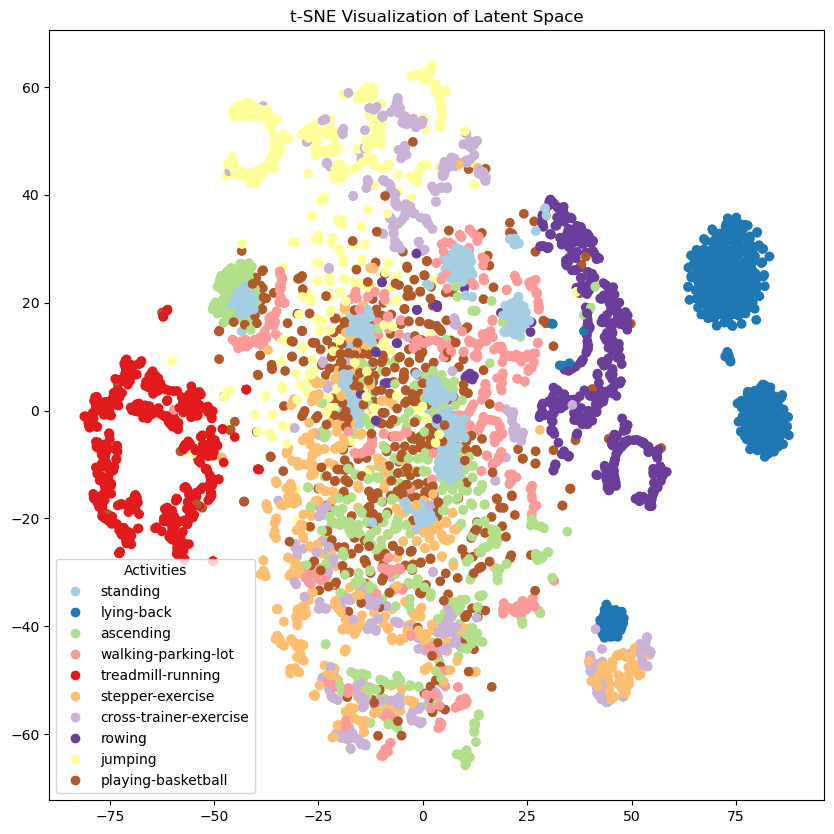

In [180]:
# https://datascience.stackexchange.com/questions/48971/what-do-we-visualize-in-showing-a-vae-latent-space
def visualize_latent_space(encoder, data_loader1, data_loader2, save_dir):
    encoder.eval()
    all_latents = []
    all_labels = []
    
    with torch.no_grad():
        for idx, (_, sample, label) in enumerate(data_loader1):
            sample, label = sample.to(DEVICE).float(), label.to(DEVICE).long()

            #Forward pass through the encoder
            mu, logvar = encoder(sample)
            z, _, _ = reparameterize(mu, logvar)
            z = z.view(z.size(0), -1)
            
            all_latents.append(z.cpu().numpy())
            all_labels.append(label.cpu().numpy())
    
    with torch.no_grad():
        for idx, (_, sample, label) in enumerate(data_loader2):
            sample, label = sample.to(DEVICE).float(), label.to(DEVICE).long()

            #Forward pass through the encoder
            mu, logvar = encoder(sample)
            z, _, _ = reparameterize(mu, logvar)
            z = z.view(z.size(0), -1)
            
            all_latents.append(z.cpu().numpy())
            all_labels.append(label.cpu().numpy())
            
    # Concatenate the lists to get the complete latent space and labels
    all_latents = np.concatenate(all_latents)
    all_labels = np.concatenate(all_labels)
    
    # Apply t-SNE for dimensionality reduction
    tsne_latents = TSNE(n_components=2, random_state=42).fit_transform(all_latents)

    # Plot the t-SNE visualization
    plt.figure(figsize=(10, 10))
    scatter = plt.scatter(tsne_latents[:, 0], tsne_latents[:, 1], c=all_labels, cmap='Paired')
    
    # Create a custom legend with the activity names
    handles, _ = scatter.legend_elements()
    plt.legend(handles, activities, title='Activities')
    plt.title('t-SNE Visualization of Latent Space')
    plt.savefig(save_dir)
    plt.show()


# Load the trained VAE model
latent_plot_save = save_path + 'latent_space'
encoder_save_path = save_path + "encoder.pth"
encoder = Encoder(latent_dim=latent_dim, init_channel=encoder_init_channel, last_channel=encoder_out_channel).to(DEVICE)
encoder.load_state_dict(torch.load(encoder_save_path))
visualize_latent_space(encoder, S_train[0], S_valid[0], latent_plot_save)

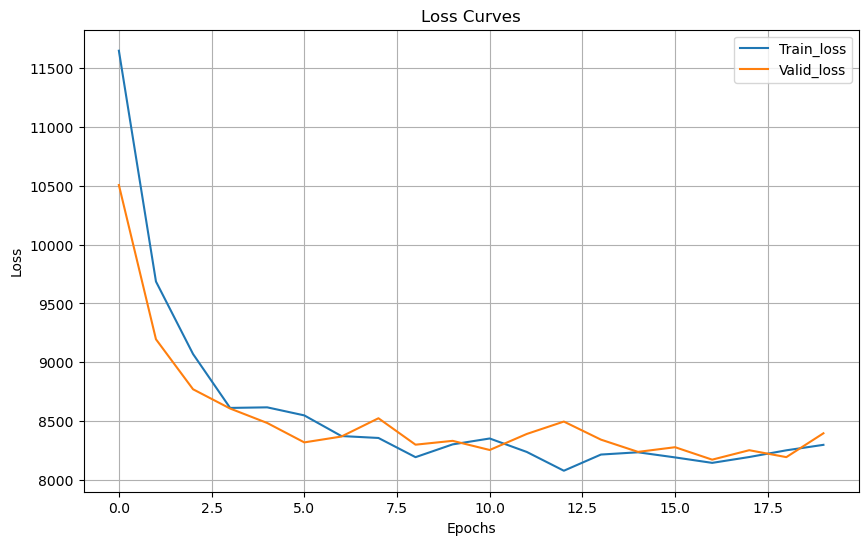

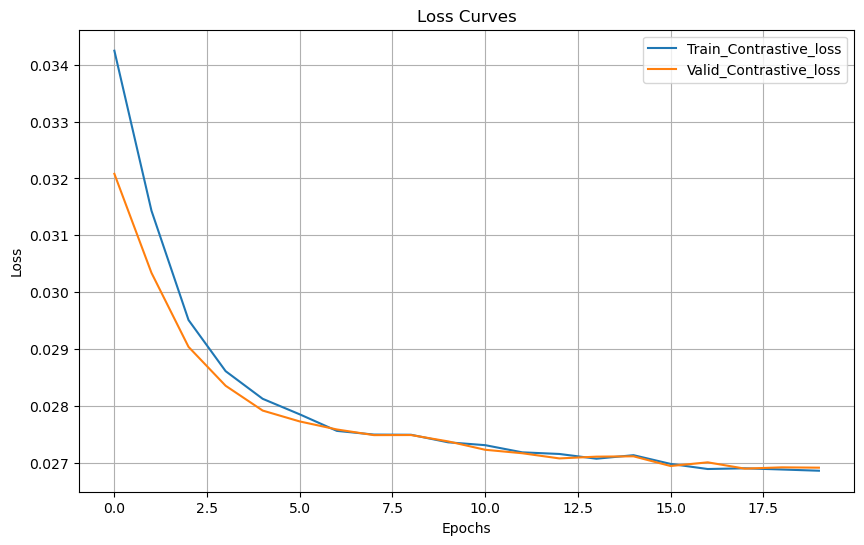

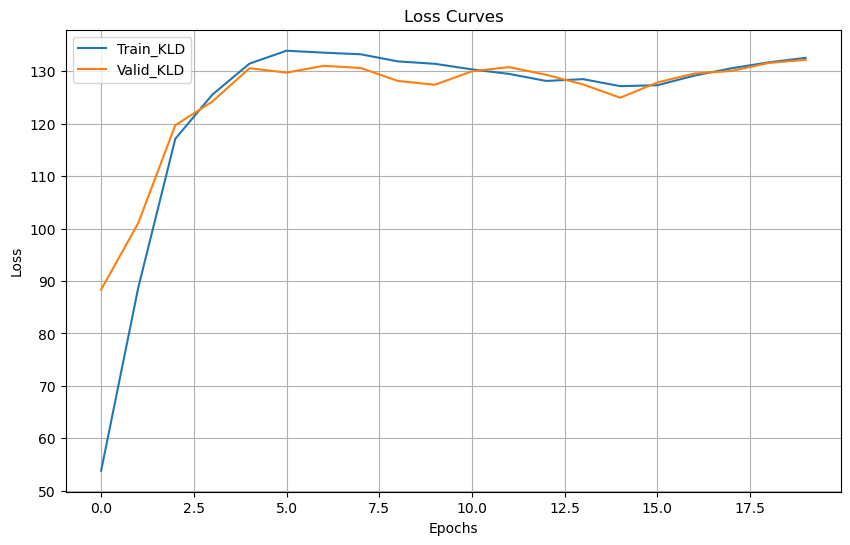

In [181]:
def plot_losses(log_file_path, losses_to_plot, plot_save_dir):
    # Initialize dictionaries to store losses
    train_losses = {
        'Train_loss': [],
        'Train_Contrastive_loss': [],
        'Train_Recon_Loss': [],
        'Train_KLD': []
    }
    valid_losses = {
        'Valid_loss': [],
        'Valid_Contrastive_loss': [],
        'Valid_Recon_Loss': [],
        'Valid_KLD': []
    }
    epochs = []

    # Read the log file and extract losses
    with open(log_file_path, 'r') as f:
        for line in f:
            if line.startswith('Epoch'):
                epoch = int(line.split(':')[1])
                epochs.append(epoch)
            elif line.startswith('Train_loss'):
                parts = line.split()
                for part in parts:
                    key, value = part.split(':')
                    train_losses[key].append(float(value))
            elif line.startswith('Valid_loss'):
                parts = line.split()
                for part in parts:
                    key, value = part.split(':')
                    valid_losses[key].append(float(value))

    # Plot the requested losses
    plt.figure(figsize=(10, 6))
    plot_name_parts = []

    for loss_name in losses_to_plot:
        if loss_name in train_losses:
            plt.plot(epochs, train_losses[loss_name], label=loss_name)
            plot_name_parts.append(loss_name)
        if loss_name in valid_losses:
            plt.plot(epochs, valid_losses[loss_name], label=loss_name)
            plot_name_parts.append(loss_name)

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Curves')
    plt.legend()
    plt.grid(True)
    
    # Generate unique plot name
    plot_name = '-'.join(plot_name_parts) + '.png'
    plot_save_dir = plot_save_dir + plot_name
    plt.savefig(plot_save_dir)
    
    # Show the plot
    plt.show()

# Example usage:
log_file_path = save_path + 'training_log.txt'
losses_to_plot = ['Train_loss', 'Valid_loss']
plot_losses(log_file_path, losses_to_plot, save_path)

losses_to_plot = ['Train_Contrastive_loss', 'Valid_Contrastive_loss']
plot_losses(log_file_path, losses_to_plot, save_path)

losses_to_plot = ['Train_KLD', 'Valid_KLD']
plot_losses(log_file_path, losses_to_plot, save_path)

# Fine-Tuning: Dowsteam Task - Classification

## Initializing Classifier

In [182]:
# =================================
# Classifier Initialization
# Optimizer Initialization
# Scheduler Initialization
# =================================
import torch.optim.lr_scheduler as lr_scheduler

#----------------------------------------
# Initializing Models
#----------------------------------------
output_gt_number = len(np.unique(s_gt_train[0]))
encoder_load_path = save_path + "encoder.pth"
encoder = Encoder(latent_dim, init_channel=encoder_init_channel, last_channel=encoder_out_channel).to(DEVICE)
encoder.load_state_dict(torch.load(encoder_load_path))

#----------------------------------------
# Optimizer and Scheduler
#----------------------------------------
classifier = Classifier(output_gt_number, infeature=latent_dim).to(DEVICE)
optimizer = optim.Adam(params=classifier.parameters(), lr=clf_lr, betas=(beta1, beta2))
criterion_classifier = nn.CrossEntropyLoss()

lr_drop_step_clf = 5 # reduce the LR every lr_drop_step epochs. 5
lr_drop_epoch_clf = 10 # keep LR constant for this number of epochs. 5
def lr_lambda_clf(epoch):
    if epoch < lr_drop_epoch_clf:
        return 1.0  # Keep the learning rate constant
    else:
        return 0.1 ** ((epoch - lr_drop_epoch_clf) // lr_drop_step_clf)  # Reduce learning rate every `step_size` epochs after `n` epochs

scheduler_clf = lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda_clf)

## Training The Classifier

In [183]:
#=========================================
# Training Log
#=========================================
log_filename = save_path + "classifier_log.txt"
log_file = open(log_filename, "w")
prevValidAcc = None #valid accuracy in previous epoch

#==========Encoder Weights Freeze============
encoder.requires_grad_(False)
#================================
# Classifier Training
#================================

# Training loop
for epoch in range(clf_epoch):
    classifier.train()
    classifierTrainLoss = 0.0
    task_correct = 0
    task_total = 0
    task_train_acc = 0
    for batch_idx, (sampleAug[0], sample[0], label[0]) in enumerate(S_train[0]):
        sampleAug[0], sample[0], label[0] = sampleAug[0].to(DEVICE).float(), sample[0].to(DEVICE).float(), label[0].to(DEVICE).long()
        for i in range(1, nsources):
            try:
                sampleAug[i], sample[i], label[i] = next(S_train_itr_list[i-1])
            except StopIteration:
                S_train_itr = iter(S_train[i])
                sampleAug[i], sample[i], label[i] = next(S_train_itr)
                
            sampleAug[i], sample[i], label[i] = sampleAug[i].to(DEVICE).float(), sample[i].to(DEVICE).float(), label[i].to(DEVICE).long()
        
        batch_sample_list = []
        batch_augsample_list = []
        batch_label_list = []
        for i in range(0, nsources):
            batch_sample_list.append(sample[i])
            batch_augsample_list.append(sampleAug[i])
            batch_label_list.append(label[i])
            
        batch_samples = torch.cat(batch_sample_list, dim=0)
        batch_augsamples = torch.cat(batch_augsample_list, dim=0)
        batch_labels = torch.cat(batch_label_list, dim=0)
        
        perm_indices = torch.randperm(batch_samples.size(0))
        # Shuffle tensors based on the generated indices
        batch_samples = batch_samples[perm_indices]
        batch_augsamples = batch_augsamples[perm_indices]
        batch_labels = batch_labels[perm_indices]
        
        #======Get mean and logvar=========
        mu, logvar = encoder(batch_samples)
        muAug, logvarAug = encoder(batch_augsamples)
        
        #======Reparameterization trick=======
        z, mu, std = reparameterize(mu, logvar)
        zAug, muAug, stdAug = reparameterize(muAug, logvarAug)
        
        #=========Classifier training========
        outputs = classifier(z.detach())
        outputsAug = classifier(zAug.detach())
        
        loss_classifier = criterion_classifier(outputs, batch_labels)
        loss_classifier_aug = criterion_classifier(outputsAug, batch_labels)
        classifierTrainLoss += loss_classifier.item()
        classifierTrainLoss += loss_classifier_aug.item()
        
        optimizer.zero_grad()
        loss_classifier.backward()
        loss_classifier_aug.backward()
        optimizer.step()
        
        _, task_pred = torch.max(outputs.data, 1)
        task_correct += (task_pred == batch_labels).sum()
        task_total += outputs.size(0)
        
    classifier.eval()
    with torch.no_grad():
        validLoss = 0.0
        validtotal = 0
        valid_correct = 0
        for vidx, (sampleAug[0], sample[0], label[0]) in enumerate(S_valid[0]):
            sampleAug[0], sample[0], label[0] = sampleAug[0].to(DEVICE).float(), sample[0].to(DEVICE).float(), label[0].to(DEVICE).long()
            for i in range(1, nsources):
                try:
                    sampleAug[i], sample[i], label[i] = next(S_valid_itr_list[i-1])
                except StopIteration:
                    S_valid_itr = iter(S_train[i])
                    sampleAug[i], sample[i], label[i] = next(S_valid_itr)

                sampleAug[i], sample[i], label[i] = sampleAug[i].to(DEVICE).float(), sample[i].to(DEVICE).float(), label[i].to(DEVICE).long()

            batch_sample_list = []
            batch_augsample_list = []
            batch_label_list = []
            for i in range(0, nsources):
                batch_sample_list.append(sample[i])
                batch_augsample_list.append(sampleAug[i])
                batch_label_list.append(label[i])

            batch_samples = torch.cat(batch_sample_list, dim=0)
            batch_augsamples = torch.cat(batch_augsample_list, dim=0)
            batch_labels = torch.cat(batch_label_list, dim=0)

            perm_indices = torch.randperm(batch_samples.size(0))
            # Shuffle tensors based on the generated indices
            batch_samples = batch_samples[perm_indices]
            batch_augsamples = batch_augsamples[perm_indices]
            batch_labels = batch_labels[perm_indices]
            
            
            vmu, vlogvar = encoder(batch_samples)
            vmuAug, vlogvarAug = encoder(batch_augsamples)
            
            vz, vmu, vstd = reparameterize(vmu, vlogvar)
            vzAug, vmuAug, vstdAug = reparameterize(vmuAug, vlogvarAug)
            
            out = classifier(vz)
            outAug = classifier(vzAug)
            
            vLoss = criterion_classifier(out, batch_labels)
            vLoss += criterion_classifier(outAug, batch_labels)
            
            validLoss += vLoss
            validtotal += batch_samples.size(0)
            
            _, valid_pred = torch.max(out.data, 1)
            valid_correct += (valid_pred == batch_labels).sum()
    
    # Step the scheduler at the end of each epoch
    scheduler_clf.step()

    #=======Print or log the average loss for the epoch========
    avgTrainLossCLF = classifierTrainLoss / task_total
    avgValidLossCLF = validLoss / validtotal
    validAcc = (float(valid_correct)*100 / validtotal)
    trainAcc = (float(task_correct) * 100/ task_total)
    
    print("=======================================")
    print(f'Epoch [{epoch + 1}/{clf_epoch}], Training Loss: {avgTrainLossCLF}')
    print(f"Epoch [{epoch + 1}/{clf_epoch}], Validation Loss: {avgValidLossCLF}")
    print(f'Epoch [{epoch + 1}/{clf_epoch}], Training Accuracy: {trainAcc}')
    print(f'Epoch [{epoch + 1}/{clf_epoch}], Validation Accuracy: {validAcc}')
    
    log_file.write(f'Epoch:{epoch}\n')
    log_file.write(f'classifier_train_loss:{avgTrainLossCLF}' + f' classifier_valid_loss:{avgValidLossCLF}' + "\n")
    log_file.write(f'classifier_train_Accuracy:{trainAcc}' + f' classifier_valid_Accuracy:{validAcc}' + "\n")
    classifier_save_path = save_path + "classifier.pth"
    
    if prevValidAcc == None:
        torch.save(classifier.state_dict(), classifier_save_path)
        prevValidAcc = validAcc
    elif validAcc >= prevValidAcc:
        torch.save(classifier.state_dict(), classifier_save_path)
        prevValidAcc = validAcc
    
log_file.close()

Epoch [1/20], Training Loss: 0.02310033171346347
Epoch [1/20], Validation Loss: 0.017696203663945198
Epoch [1/20], Training Accuracy: 52.57828614288393
Epoch [1/20], Validation Accuracy: 67.4123788217748
Epoch [2/20], Training Loss: 0.015837541918686325
Epoch [2/20], Validation Loss: 0.014865991659462452
Epoch [2/20], Training Accuracy: 72.2170135633477
Epoch [2/20], Validation Accuracy: 75.78299776286353
Epoch [3/20], Training Loss: 0.013711492229874517
Epoch [3/20], Validation Loss: 0.013353213667869568
Epoch [3/20], Training Accuracy: 77.7486092880805
Epoch [3/20], Validation Accuracy: 78.52348993288591
Epoch [4/20], Training Loss: 0.01235118431034323
Epoch [4/20], Validation Loss: 0.013135170564055443
Epoch [4/20], Training Accuracy: 81.21757609850616
Epoch [4/20], Validation Accuracy: 80.66741237882178
Epoch [5/20], Training Loss: 0.01175084031330838
Epoch [5/20], Validation Loss: 0.012345720082521439
Epoch [5/20], Training Accuracy: 82.96143508969311
Epoch [5/20], Validation Accu

# Visualization - Fine Tune - Metrics

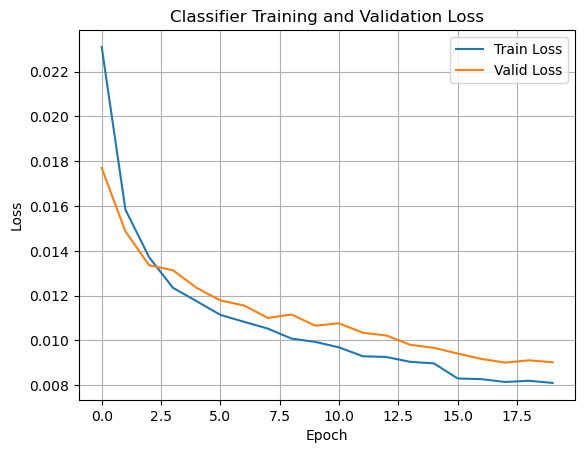

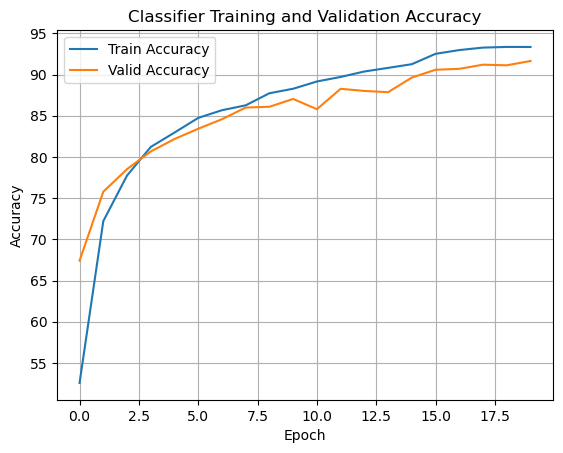

In [184]:
import matplotlib.pyplot as plt

def plot_classifier_metrics(log_file_path, save_dir):
    # Initialize lists to hold values
    train_loss = []
    valid_loss = []
    train_acc = []
    valid_acc = []
    
    # Read the log file
    with open(log_file_path, 'r') as log_file:
        lines = log_file.readlines()
    
    for line in lines:
        if 'classifier_train_loss' in line:
            train_loss.append(float(line.split('classifier_train_loss:')[1].split()[0]))
            valid_loss.append(float(line.split('classifier_valid_loss:')[1].strip()))
        elif 'classifier_train_Accuracy' in line:
            train_acc.append(float(line.split('classifier_train_Accuracy:')[1].split()[0]))
            valid_acc.append(float(line.split('classifier_valid_Accuracy:')[1].strip()))
    
    # Plot training and validation loss
    plt.figure()
    plt.plot(train_loss, label='Train Loss')
    plt.plot(valid_loss, label='Valid Loss')
    plt.title('Classifier Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plot_name_loss = "Classifier_TrainLoss_ValidLoss.png"
    clf_loss_save = save_dir + plot_name_loss
    plt.savefig(clf_loss_save)
    plt.show()
    
    # Plot training and validation accuracy
    plt.figure()
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(valid_acc, label='Valid Accuracy')
    plt.title('Classifier Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plot_name_acc = "Classifier_TrainAcc_ValidAcc.png"
    clf_acc_save = save_dir + plot_name_acc
    plt.savefig(clf_acc_save)
    plt.show()

# Example usage
log_file_path = save_path + "classifier_log.txt"
save_dir = save_path
plot_classifier_metrics(log_file_path, save_dir)

# Testing on Target Domain

Dataset: DSADS, all persons
Test_accuracy_target-LL: 67.26726726726727
Test_precision_target-LL: 0.6726726726726727
Test_recall_target-LL: 0.6726726726726727
Test_f1_target-LL: 0.6726726726726727


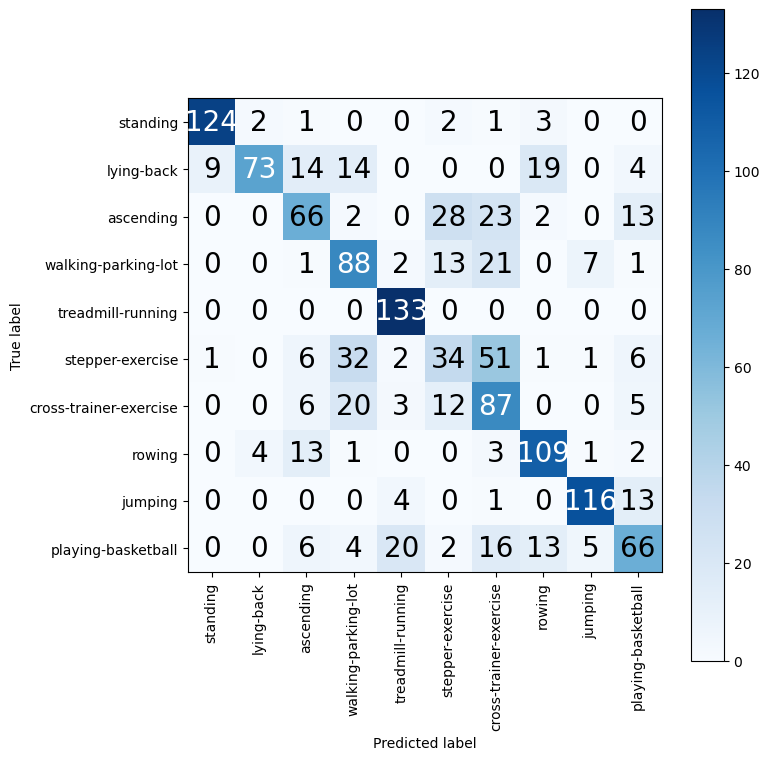

In [185]:
#===================================
# Load Classifier
#===================================
output_gt_number = len(np.unique(s_gt_train[0]))
classifier = Classifier(output_gt_number, infeature=latent_dim).to(DEVICE)
classifier_load_path = save_path + "classifier.pth"
classifier.load_state_dict(torch.load(classifier_load_path))

#===================================
# Logging
#===================================
test_filename = save_path + 'result.txt'
test_file = open(test_filename, "w")

#===================================
# Load Encoder
#===================================
encoder = Encoder(latent_dim, init_channel=encoder_init_channel, last_channel=encoder_out_channel).to(DEVICE)
encoder_load_path = save_path + "encoder.pth"
encoder.load_state_dict(torch.load(encoder_load_path))

#====================================
# Classifier Testing
#====================================
classifier.eval()
encoder.eval()
with torch.no_grad():
    task_correct = 0
    task_total = 0
    all_preds = []
    all_labels = []
    
    for vidx, (_, testSample, testLabel) in enumerate(T_test):
        testSample, testLabel = testSample.to(DEVICE).float(), testLabel.to(DEVICE).long()
        # Get mean and logvar
        mu, logvar = encoder(testSample)

        # Reparameterization trick
        z, _, _ = reparameterize(mu, logvar)

        # outputs
        pred = classifier(z)

        _, task_pred = torch.max(pred.data, 1)
        all_preds.extend(task_pred.cpu().numpy())
        all_labels.extend(testLabel.cpu().numpy())

        task_correct += (task_pred == testLabel).sum()
        task_total += pred.size(0)
        
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    testAcc = float(task_correct) * 100 / task_total
    precision = precision_score(all_labels, all_preds, average='micro')
    recall = recall_score(all_labels, all_preds, average='micro')
    f1 = f1_score(all_labels, all_preds, average='micro')
    
    if task == "Cross-Position":
        print(f"Dataset: {dataset}, all persons")
        print(f"Test_accuracy_target-{domains[target]}: {testAcc}")
        print(f"Test_precision_target-{domains[target]}: {precision}")
        print(f"Test_recall_target-{domains[target]}: {recall}")
        print(f"Test_f1_target-{domains[target]}: {f1}")

        test_file.write(f"Dataset: {dataset}, all persons\n")
        test_file.write(f"Test_accuracy_target-{domains[target]}:{testAcc}\n")
        test_file.write(f"Test_precision_target-{domains[target]}:{precision}\n")
        test_file.write(f"Test_recall_target-{domains[target]}:{recall}\n")
        test_file.write(f"Test_f1_target-{domains[target]}:{f1}\n")
        
    elif task == "Cross-Person":
        target_string = ", ".join([domains[i] for i in target])
        print(f"Dataset: {dataset}, all Positions")
        print(f"Test_accuracy_target-({target_string}): {testAcc}")
        print(f"Test_precision_target-({target_string}): {precision}")
        print(f"Test_recall_target-({target_string}): {recall}")
        print(f"Test_f1_target-({target_string}): {f1}")

        test_file.write(f"Dataset: {dataset}, all positions\n")
        test_file.write(f"Test_accuracy_target-({target_string}):{testAcc}\n")
        test_file.write(f"Test_precision_target-({target_string}):{precision}\n")
        test_file.write(f"Test_recall_target-({target_string}):{recall}\n")
        test_file.write(f"Test_f1_target-({target_string}):{f1}\n")
        
    test_file.close()
    # Compute the confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    # Plot and save the confusion matrix
    plot_save_path = save_path  # Save path for the confusion matrix plot
    plot_confusion_matrix(cm, classes=activities, normalize=False, title='Confusion_Matrix', plot_save_path=plot_save_path, show=True)